In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import funkyheatmappy

plt.figure(figsize=(32, 24))

<Figure size 3200x2400 with 0 Axes>

<Figure size 3200x2400 with 0 Axes>

In [ ]:
benchmark_df = pd.read_csv("pancreas_benchmark_df.csv", index_col=0)
benchmark_df.loc["ti_slingshot", "type"] = "directed"
benchmark_df

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,geom_mean,arith_mean,id,type,prior_level,time,time_text,memory,memory_text,overall
scvelo,0.995,0.769,0.894,1.0,1.000,0.961,0.882,1.000,1.000,1.000,...,0.991,0.991,scvelo,Velocity,free,14.000,14s,920.62,921M,0.926
velovi,0.995,0.780,0.921,1.0,1.000,0.961,0.882,1.000,1.000,1.000,...,0.991,0.991,velovi,Velocity,free,331.190,6min,2329.13,2G,0.929
dynamo,0.538,0.764,0.886,0.0,0.500,0.560,0.779,0.775,0.941,0.989,...,0.076,0.076,dynamo,Velocity,strong restricted,125.330,2min,5503.20,5G,0.650
pyrovelocity,0.915,0.572,0.784,0.0,0.750,0.528,0.838,0.801,0.944,0.998,...,0.830,0.830,pyrovelocity,Velocity,free,672.870,11min,14051.57,14G,0.686
veloae,0.484,0.410,0.918,0.0,0.500,0.574,0.789,0.923,0.932,0.997,...,-0.032,-0.032,veloae,Velocity,free,37.120,37s,2283.07,2G,0.569
unitvelo,0.846,0.745,0.952,0.0,0.500,0.341,0.799,0.715,0.920,0.995,...,0.692,0.692,unitvelo,Velocity,strong restricted,482.830,8min,3624.93,4G,0.626
comp1,0.950,0.678,1.000,0.0,0.000,0.267,0.500,0.189,0.281,0.852,...,0.281,0.281,comp1,Linear,weakly restricted,0.000,0s,0.00,0M,0.425
palantir,0.991,0.687,1.000,0.0,0.000,0.267,0.674,0.189,0.272,0.891,...,0.982,0.982,palantir,Linear,strong restricted,0.000,0s,0.00,0M,0.431
cytotrace2,0.870,0.655,1.000,0.0,0.000,0.267,0.096,0.189,0.282,0.757,...,0.740,0.740,cytotrace2,Linear,weakly restricted,0.000,0s,0.00,0M,0.412
sctc,0.485,0.322,1.000,0.0,0.000,0.267,0.000,0.189,0.284,0.820,...,-0.030,-0.030,sctc,Linear,free,0.000,0s,0.00,0M,0.298


Some palettes were not used in the column info, adding legends for them:white6black4, resource_palette, metric_palette
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True, 'geom': 'text'} did not contain labels, inferring from the geom.
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True, 'geom': 'text'} has geom 'text' but no specified labels, so disabling this legend for now.
Legend {'title': 'resource_palette', 'palette': 'resource_palette', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'resource_palette', 'palette': 'resource_palette', 'enabled': True, 'geom': 'rect'} did not contain labels, inferring from the geom.
Legend {'title': 'resource_palette', 'palette': 'resource_palette', 'enabled': True, 'geom': 'rect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6

<Figure size 2400x1600 with 0 Axes>

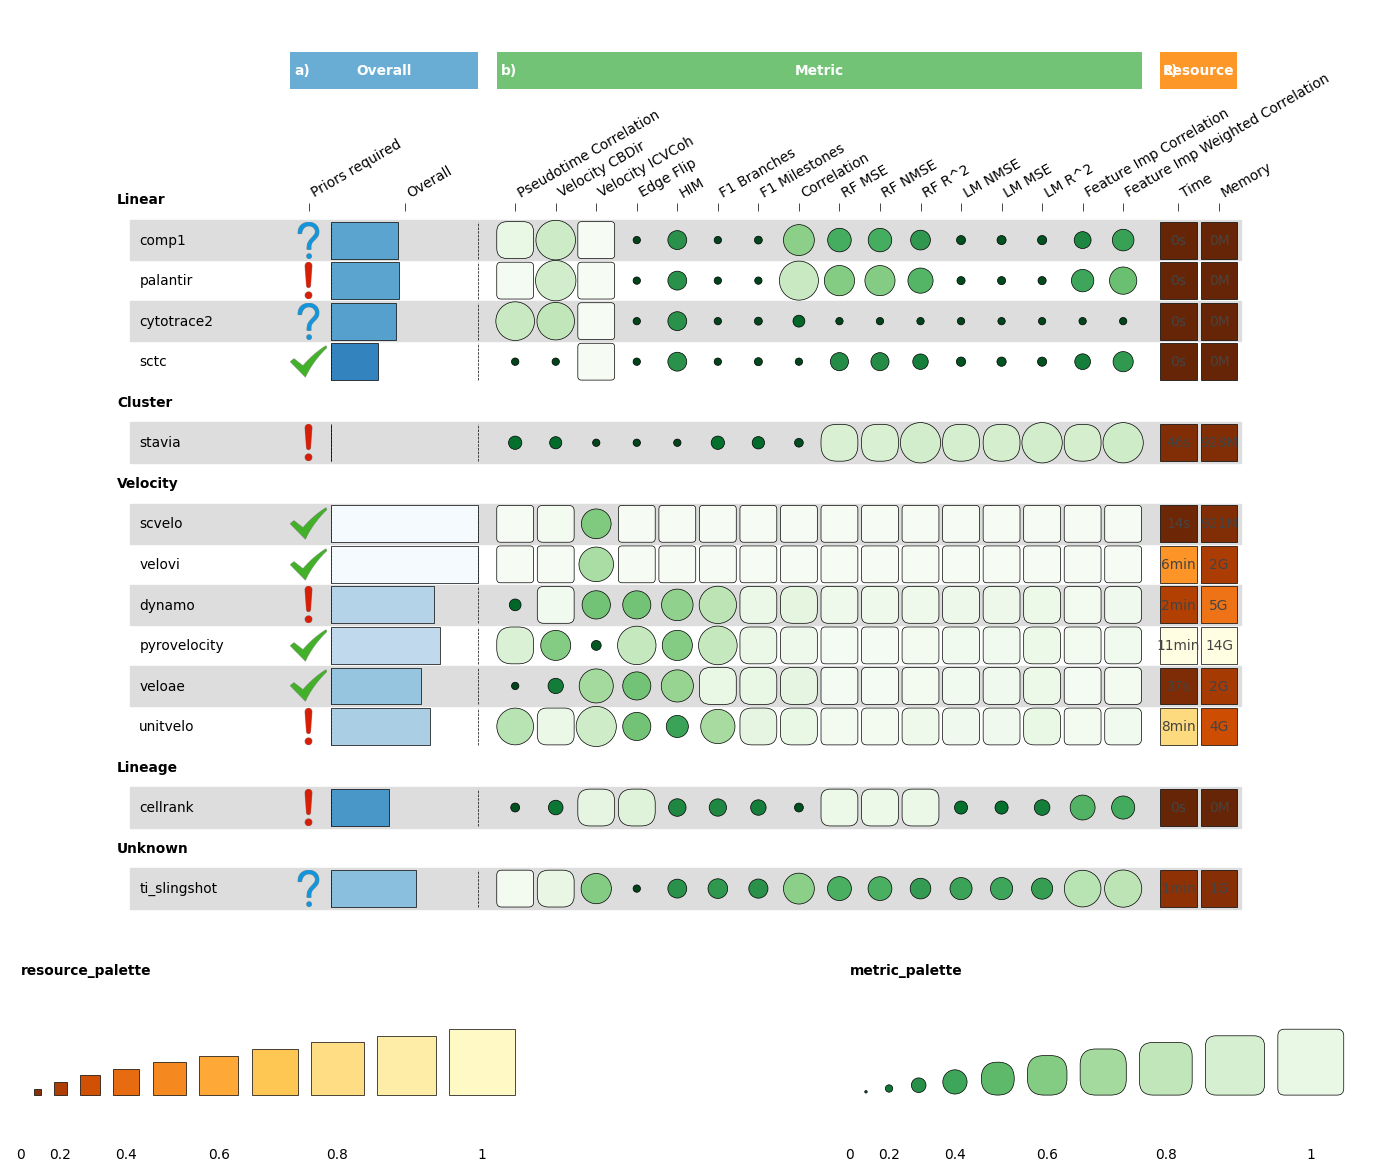

In [8]:
import matplotlib.pyplot as plt
import funkyheatmappy

plt.figure(figsize=(24, 16))

# 样式参考dynbenchmark: https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html
column_list = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 4}, np.nan],
    # ["type", np.nan, "Wrapper Type", "text", {"ha": 0, "width": 4}, np.nan],
    ["prior_level", "overall", "Priors required", "text", {}, np.nan],
]


if "overall" in benchmark_df.columns:
    column_list.append(["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "overall_palette"])

# accuracy metrics
id2name = {
    "pseudotime_correlation": "Pseudotime Correlation",
    "velocity_cbdir": "Velocity CBDir",
    "velocity_icvcoh": "Velocity ICVCoh",
    "edge_flip": "Edge Flip",
    "him": "HIM",
    # "isomorphic": "Isomorphic",
    "F1_branches": "F1 Branches",
    "F1_milestones": "F1 Milestones",
    "correlation": "Correlation",
    "rf_mse": "RF MSE",
    "rf_nmse": "RF NMSE",
    "rf_rsq": "RF R^2",
    "lm_nmse": "LM NMSE",
    "lm_mse": "LM MSE",
    "lm_rsq": "LM R^2",
    "featureimp_cor": "Feature Imp Correlation",
    "featureimp_wcor": "Feature Imp Weighted Correlation",
}

metric_column_list = []
for id, name in id2name.items():
    if id in benchmark_df.columns:
        metric_column_list.append([id, "metric", name, "funkyrect", "options", "metric_palette"])
column_list = column_list[:4] + metric_column_list + column_list[4:]

# resource group
if "time" in benchmark_df.columns:
    column_list.append(["time", "resource", "Time", "rect", "scaling", "resource_palette"])
    column_list.append(["time_text", "resource", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"])

if "memory" in benchmark_df.columns:
    column_list.append(["memory", "resource", "Memory", "rect", "scaling", "resource_palette"])
    column_list.append(["memory_text", "resource", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"])

column_info = pd.DataFrame(column_list[1:], columns=column_list[0])
column_info.index = column_info["id"]

# set 
column_info.loc["prior_level", "path"] = "img/funkeyheatmap/"
column_info.loc["prior_level", "filetype"] = "png"
column_info.loc["prior_level", "geom"] = "image"

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[["Overall", "overall", "overall_palette"],
          ["Metric", "metric", "metric_palette"],
          ["Resource", "resource", "resource_palette"]]
)

# Define row groups (order matters)
group_list = ["Linear", "Cluster", "Velocity", "Lineage", "Unknown"]
row_groups = pd.DataFrame({"group": group_list, "Group": group_list})

# Row annotation and grouping
row_info = benchmark_df[["type"]].rename(columns={"type": "group"})
row_info["id"] = row_info.index  # Ensure 'id' column exists for the text column in visualization
row_info["group"] = pd.Categorical(row_info["group"], categories=group_list, ordered=True) # TODO: 暂时只根据group类型排序，group内部可以进一步使用总评分进行排序。
row_info = row_info.sort_values("group")

# sort benchmark_df according to row_info
benchmark_df = benchmark_df.loc[row_info.index]

# palette definitions
palettes = {
    "overall_palette": "Blues",
    "metric_palette": "Greens",
    "resource_palette": "YlOrBr",
}

# legends
legends = [
    {"palette": "overall_palette", "enabled": False},
]


funkyheatmappy.funky_heatmap(
    benchmark_df,
    column_info=column_info, 
    column_groups=column_groups,
    row_info=row_info,
    row_groups=row_groups,
    palettes=palettes,
    legends=legends,
)
plt.savefig("benchmark_heatmap.pdf", dpi=300)